Day - Night operational pattern using Light and Noise

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
node1 = pd.read_csv('/content/Dataset-AAKTP-Node 1 Baby chick section.csv')
node2 = pd.read_csv('/content/Dataset-AAKTP-Node 2 Main-East-Zone.csv')
node3 = pd.read_csv('/content/Dataset-AAKTP-Node 3 Main West-Zone.csv')

for df in [node1, node2, node3]:
    df['Time'] = pd.to_datetime(df['Time'], format='%d/%m/%Y %H:%M') # Convert 'Time' column to datetime objects
    df['Hour'] = df['Time'].dt.hour

hourly_ops = pd.DataFrame({
    'Node1_Light': node1.groupby('Hour')['Light'].median(),
    'Node2_Light': node2.groupby('Hour')['Light'].median(),
    'Node3_Light': node3.groupby('Hour')['Light'].median(),
    'Node1_NoiseAvg': node1.groupby('Hour')['Noise-Avg'].median(),
    'Node2_NoiseAvg': node2.groupby('Hour')['Noise-Avg'].median(),
    'Node3_NoiseAvg': node3.groupby('Hour')['Noise-Avg'].median(),
    'Node1_NoisePeak': node1.groupby('Hour')['Noise-Peak'].median(),
    'Node2_NoisePeak': node2.groupby('Hour')['Noise-Peak'].median(),
    'Node3_NoisePeak': node3.groupby('Hour')['Noise-Peak'].median(),
})

Light Visual

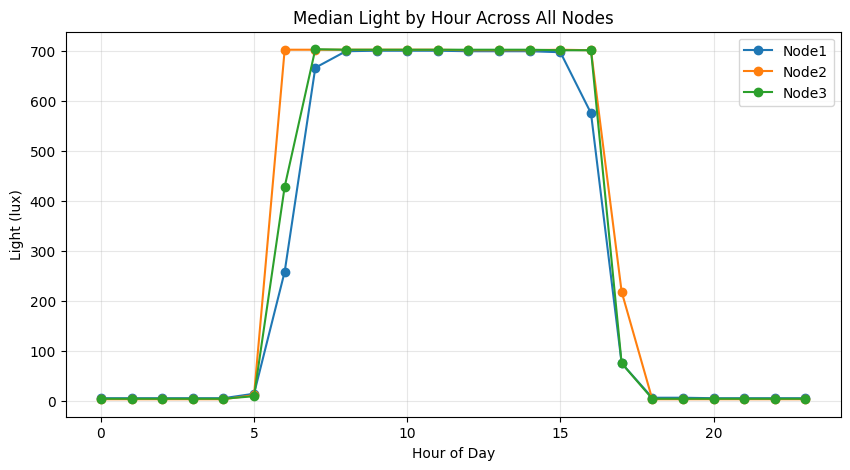

In [2]:
plt.figure(figsize=(10,5))
plt.plot(hourly_ops.index, hourly_ops['Node1_Light'], marker='o', label='Node1')
plt.plot(hourly_ops.index, hourly_ops['Node2_Light'], marker='o', label='Node2')
plt.plot(hourly_ops.index, hourly_ops['Node3_Light'], marker='o', label='Node3')

plt.title('Median Light by Hour Across All Nodes')
plt.xlabel('Hour of Day')
plt.ylabel('Light (lux)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Noise Average Visual

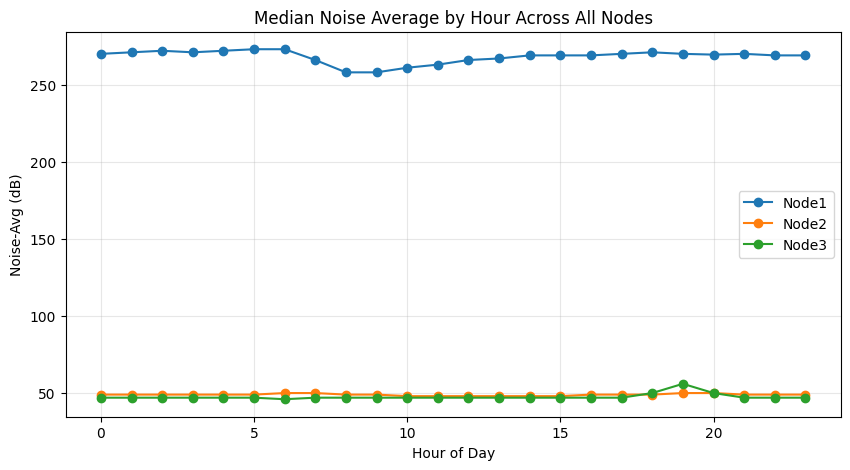

In [3]:
plt.figure(figsize=(10,5))
plt.plot(hourly_ops.index, hourly_ops['Node1_NoiseAvg'], marker='o', label='Node1')
plt.plot(hourly_ops.index, hourly_ops['Node2_NoiseAvg'], marker='o', label='Node2')
plt.plot(hourly_ops.index, hourly_ops['Node3_NoiseAvg'], marker='o', label='Node3')

plt.title('Median Noise Average by Hour Across All Nodes')
plt.xlabel('Hour of Day')
plt.ylabel('Noise-Avg (dB)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Noise Peak Visual

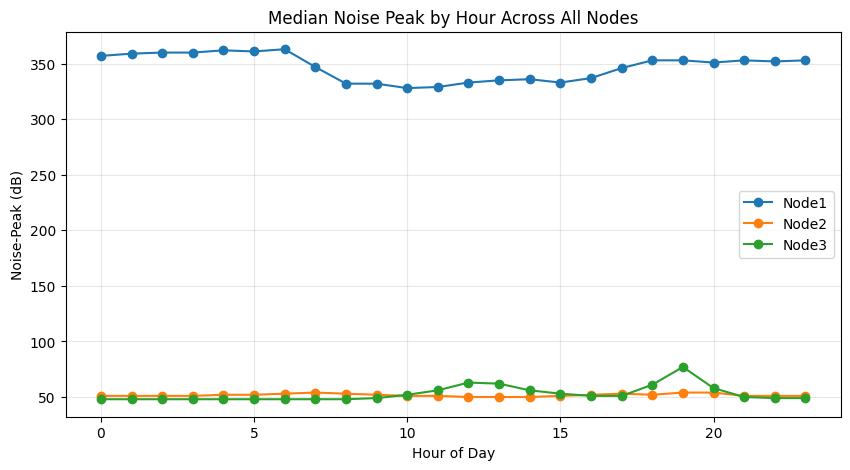

In [4]:
plt.figure(figsize=(10,5))
plt.plot(hourly_ops.index, hourly_ops['Node1_NoisePeak'], marker='o', label='Node1')
plt.plot(hourly_ops.index, hourly_ops['Node2_NoisePeak'], marker='o', label='Node2')
plt.plot(hourly_ops.index, hourly_ops['Node3_NoisePeak'], marker='o', label='Node3')

plt.title('Median Noise Peak by Hour Across All Nodes')
plt.xlabel('Hour of Day')
plt.ylabel('Noise-Peak (dB)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

> Light follows a daily schedule

> Noise may rises at feeding, cleaning, or active times

> Node one / Baby chick section is consistently noisier than others

Daily Temperature & Humidity Cycle

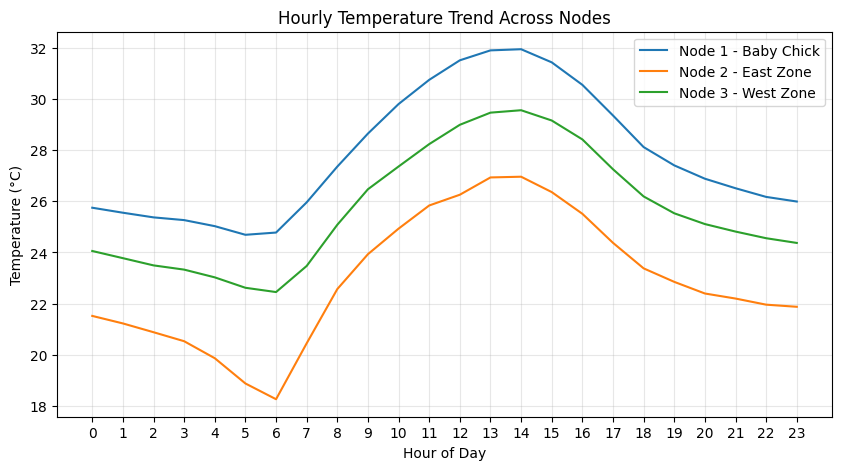

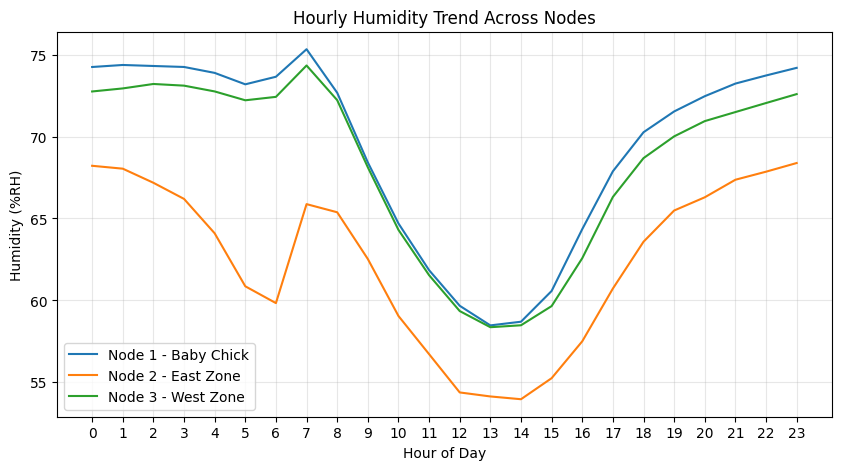

In [5]:
# Hourly averages
hourly1 = node1.groupby('Hour')[['Temperature', 'Humidity']].mean()
hourly2 = node2.groupby('Hour')[['Temperature', 'Humidity']].mean()
hourly3 = node3.groupby('Hour')[['Temperature', 'Humidity']].mean()

# Temperature plot
plt.figure(figsize=(10,5))
plt.plot(hourly1.index, hourly1['Temperature'], label='Node 1 - Baby Chick')
plt.plot(hourly2.index, hourly2['Temperature'], label='Node 2 - East Zone')
plt.plot(hourly3.index, hourly3['Temperature'], label='Node 3 - West Zone')
plt.title('Hourly Temperature Trend Across Nodes')
plt.xlabel('Hour of Day')
plt.ylabel('Temperature (°C)')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Humidity plot
plt.figure(figsize=(10,5))
plt.plot(hourly1.index, hourly1['Humidity'], label='Node 1 - Baby Chick')
plt.plot(hourly2.index, hourly2['Humidity'], label='Node 2 - East Zone')
plt.plot(hourly3.index, hourly3['Humidity'], label='Node 3 - West Zone')
plt.title('Hourly Humidity Trend Across Nodes')
plt.xlabel('Hour of Day')
plt.ylabel('Humidity (%RH)')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

> Conditions are fluctuating through the day

> Baby chicks are kept warmer than the grow-out zones

> Humidity moves inversely to temperature

NH3 As A Farm Air-Quality Risk

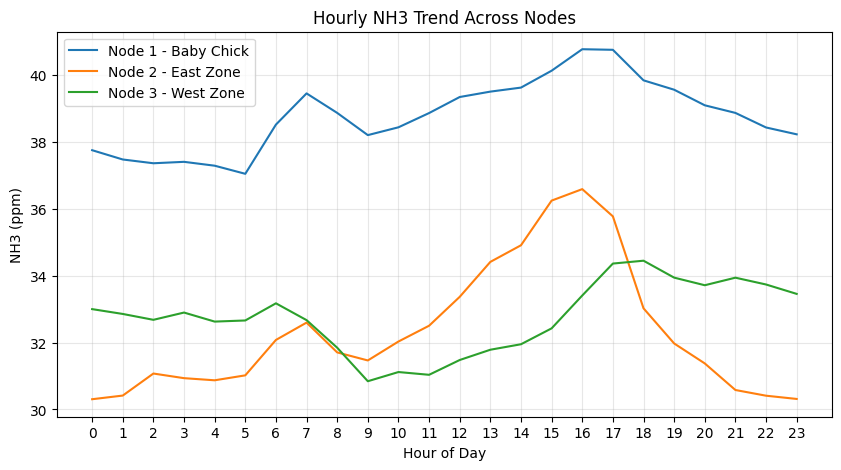

In [6]:
hourly_nh3_1 = node1.groupby('Hour')['NH3'].mean()
hourly_nh3_2 = node2.groupby('Hour')['NH3'].mean()
hourly_nh3_3 = node3.groupby('Hour')['NH3'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_nh3_1.index, hourly_nh3_1.values, label='Node 1 - Baby Chick')
plt.plot(hourly_nh3_2.index, hourly_nh3_2.values, label='Node 2 - East Zone')
plt.plot(hourly_nh3_3.index, hourly_nh3_3.values, label='Node 3 - West Zone')
plt.title('Hourly NH3 Trend Across Nodes')
plt.xlabel('Hour of Day')
plt.ylabel('NH3 (ppm)')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

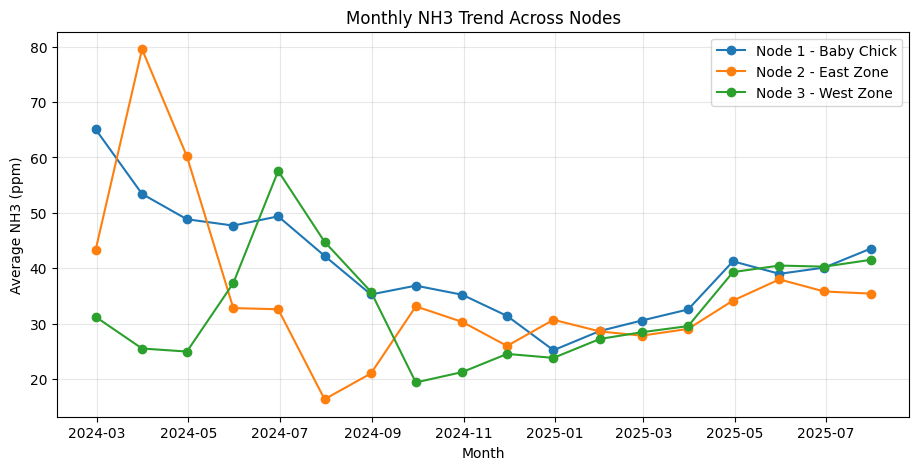

In [7]:
monthly1 = node1.set_index('Time').resample('ME')['NH3'].mean()
monthly2 = node2.set_index('Time').resample('ME')['NH3'].mean()
monthly3 = node3.set_index('Time').resample('ME')['NH3'].mean()

plt.figure(figsize=(11,5))
plt.plot(monthly1.index, monthly1.values, marker='o', label='Node 1 - Baby Chick')
plt.plot(monthly2.index, monthly2.values, marker='o', label='Node 2 - East Zone')
plt.plot(monthly3.index, monthly3.values, marker='o', label='Node 3 - West Zone')
plt.title('Monthly NH3 Trend Across Nodes')
plt.xlabel('Month')
plt.ylabel('Average NH3 (ppm)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

> NH3 trend suggests that ammonia levels increase gradually during the day (hourly trend) and are highest in Node 1 on average, indicating that the baby chick section may be more enclosed to waste-related gas accumulation.

> If we look into the monthly trend, we find other nodes (2,3) has NH3 spikes for initial period and after that - their levels are comparatively lower on average.

> If NH3 rises, this may indicate that ventilation, litter condition, or waste management is not fully offsetting gas build-up during active farm operations.

Dust and disturbance pattern in grow-out zones

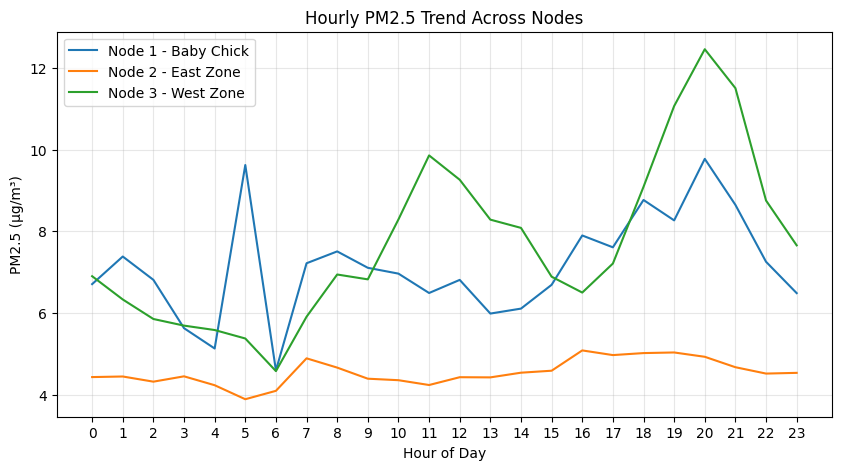

In [18]:
hourly_pm25_1 = node1.groupby('Hour')['PM2-5'].mean()
hourly_pm25_2 = node2.groupby('Hour')['PM2-5'].mean()
hourly_pm25_3 = node3.groupby('Hour')['PM2-5'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_pm25_1.index, hourly_pm25_1.values, label='Node 1 - Baby Chick')
plt.plot(hourly_pm25_2.index, hourly_pm25_2.values, label='Node 2 - East Zone')
plt.plot(hourly_pm25_3.index, hourly_pm25_3.values, label='Node 3 - West Zone')
plt.title('Hourly PM2.5 Trend Across Nodes')
plt.xlabel('Hour of Day')
plt.ylabel('PM2.5 (µg/m³)')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

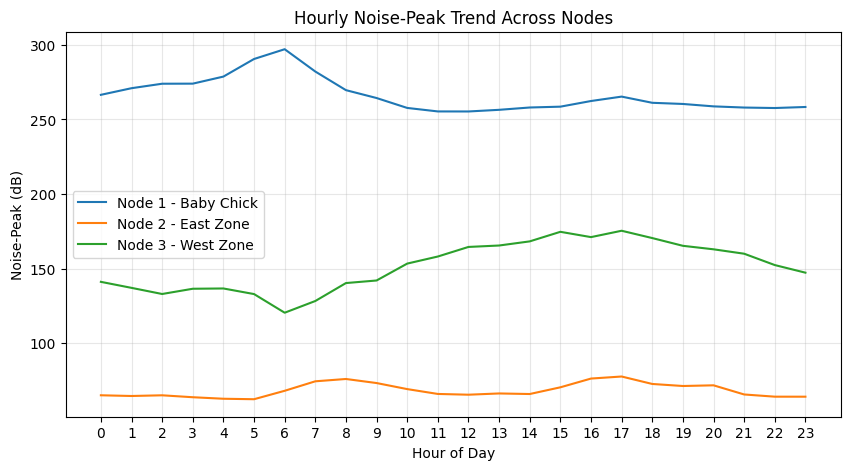

In [9]:
hourly_noise_1 = node1.groupby('Hour')['Noise-Peak'].mean()
hourly_noise_2 = node2.groupby('Hour')['Noise-Peak'].mean()
hourly_noise_3 = node3.groupby('Hour')['Noise-Peak'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_noise_1.index, hourly_noise_1.values, label='Node 1 - Baby Chick')
plt.plot(hourly_noise_2.index, hourly_noise_2.values, label='Node 2 - East Zone')
plt.plot(hourly_noise_3.index, hourly_noise_3.values, label='Node 3 - West Zone')
plt.title('Hourly Noise-Peak Trend Across Nodes')
plt.xlabel('Hour of Day')
plt.ylabel('Noise-Peak (dB)')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

> Node 3 shows stronger variation in PM2.5 than Node 2, suggesting that the West grow-out zone may experience more dust-related disturbance or weaker local ventilation.

> Noise levels are also notably higher in Node 1 and Node 3 than in Node 2, indicating that disturbance conditions are not evenly distributed across the farm.

Summary

In [10]:
summary = pd.DataFrame({
    'Metric': ['Mean Temperature', 'Mean Humidity', 'Mean NH3', 'Mean PM2.5', 'Mean Noise-Peak'],
    'Node 1': [
        node1['Temperature'].mean(),
        node1['Humidity'].mean(),
        node1['NH3'].mean(),
        node1['PM2-5'].mean(),
        node1['Noise-Peak'].mean()
    ],
    'Node 2': [
        node2['Temperature'].mean(),
        node2['Humidity'].mean(),
        node2['NH3'].mean(),
        node2['PM2-5'].mean(),
        node2['Noise-Peak'].mean()
    ],
    'Node 3': [
        node3['Temperature'].mean(),
        node3['Humidity'].mean(),
        node3['NH3'].mean(),
        node3['PM2-5'].mean(),
        node3['Noise-Peak'].mean()
    ]
})

summary = summary.round(2)
summary

,Metric,Node 1,Node 2,Node 3
0,Mean Temperature,27.97,23.19,25.89
1,Mean Humidity,69.09,62.38,68.01
2,Mean NH3,38.85,32.41,32.77
3,Mean PM2.5,7.20,4.57,7.89
4,Mean Noise-Peak,264.86,68.52,153.19
